In [1]:
#import libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1784481447.194007  103484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784481447.194483  103484 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784481447.232832  103484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784481447.717363  103484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
#load data
two_df = pd.read_csv('/home/yvonne_chook/github/207-Summer26-FinalProject-MLModel/Merged_EDA/combined_data/combined_data_2h.csv')

four_df = pd.read_csv('/home/yvonne_chook/github/207-Summer26-FinalProject-MLModel/Merged_EDA/combined_data/combined_data_4h.csv')

In [3]:
# check distribution of data across years

yearly_distribution = two_df.groupby('year').size()
print(yearly_distribution)

year
2022.0    69408
2023.0    82554
2024.0    84932
2025.0    82202
2026.0    16822
dtype: int64


In [4]:
#split train validation and test data

#Do this for 2 hr data
two_train_df = two_df[
    (two_df["date"] >= "2022-01-01") &
    (two_df["date"] <= "2023-12-31")
]

two_validation_df = two_df[
    (two_df["date"] >= "2024-01-01") &
    (two_df["date"] <= "2024-12-31")
]

two_test_df = two_df[
    (two_df["date"] >= "2025-01-01") &
    (two_df["date"] <= "2026-06-09")
]

#Do this for 4 hr data
four_train_df = four_df[
    (four_df["date"] >= "2022-01-01") &
    (four_df["date"] <= "2023-12-31")
]

four_validation_df = four_df[
    (four_df["date"] >= "2024-01-01") &
    (four_df["date"] <= "2024-12-31")
]

four_test_df = four_df[
    (four_df["date"] >= "2025-01-01") &
    (four_df["date"] <= "2026-06-09")
]

#print shape of each
print("2hr data:")
print("Train shape:", two_train_df.shape)
print("Validation shape:", two_validation_df.shape)
print("Test shape:", two_test_df.shape)

print("\n4hr data:")
print("Train shape:", four_train_df.shape)
print("Validation shape:", four_validation_df.shape)
print("Test shape:", four_test_df.shape)

2hr data:
Train shape: (151962, 32)
Validation shape: (84932, 32)
Test shape: (99024, 32)

4hr data:
Train shape: (154285, 32)
Validation shape: (86039, 32)
Test shape: (99672, 32)


In [5]:
#feature selection

numeric_features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h"
]

categorical_features = [
    "carrier_code",
    "destination_airport",
    "model"
]

features = numeric_features + categorical_features

target = "outcome"

**2 hour improved model**

In [6]:
# create X and y

#2 hr
two_X_train = two_train_df[features]
two_y_train = two_train_df[target]

two_X_val = two_validation_df[features]
two_y_val = two_validation_df[target]

two_X_test = two_test_df[features]
two_y_test = two_test_df[target]

#4hr
four_X_train = four_train_df[features]
four_y_train = four_train_df[target]

four_X_val = four_validation_df[features]
four_y_val = four_validation_df[target]

four_X_test = four_test_df[features]
four_y_test = four_test_df[target]

In [7]:
#building prepreocessing pipeline
# scale features
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# fill missing values and one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# Apply the correct transformation to each column type
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

In [8]:
# Fit only on training data
#2hr
two_X_train_processed = preprocessor.fit_transform(two_X_train)

# Apply the same fitted transformations to validation and test data
two_X_val_processed = preprocessor.transform(two_X_val)
two_X_test_processed = preprocessor.transform(two_X_test)

print("2 hr Training shape:", two_X_train_processed.shape)
print("2 hr Validation shape:", two_X_val_processed.shape)
print("2 hr Test shape:", two_X_test_processed.shape)

#4hr
four_X_train_processed = preprocessor.fit_transform(four_X_train)
four_X_val_processed = preprocessor.transform(four_X_val)
four_X_test_processed = preprocessor.transform(four_X_test)

print("\n")
print("4 hr Training shape:", four_X_train_processed.shape)
print("4 hr Validation shape:", four_X_val_processed.shape)
print("4 hr Test shape:", four_X_test_processed.shape)

2 hr Training shape: (151962, 170)
2 hr Validation shape: (84932, 170)
2 hr Test shape: (99024, 170)


4 hr Training shape: (154285, 170)
4 hr Validation shape: (86039, 170)
4 hr Test shape: (99672, 170)


**Random Forest Model**

In [9]:
# random forest classifier

# rf_model = RandomForestClassifier( #ard 75% training and val accuracy | 50% test accuracy
#     n_estimators=200,
#     max_depth=20,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     class_weight="balanced",
#     random_state=1234,
#     n_jobs=-1
# )

# rf_model = RandomForestClassifier( # shallower tress, more trees, more samples per split and leaf | 40training and val accuracy | 35% test accuracy
#     n_estimators=300,
#     max_depth=12,
#     min_samples_split=20,
#     min_samples_leaf=10,
#     class_weight="balanced",
#     max_features="sqrt",
#     random_state=1234,
#     n_jobs=-1
# )

rf_model = RandomForestClassifier( # deeper trees, more trees, more samples per split and leaf |80 training and val accuracy | 55% test accuracy
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=None,
    class_weight="balanced",
    random_state=1234,
    n_jobs=-1
)

**Random Forest Classifier Two Hour**

In [10]:
# random forest


# train the model
rf_model.fit(two_X_train_processed, two_y_train)

# evaluate accuracy on the model

# predict train, validation, and test data
two_y_train_pred = rf_model.predict(two_X_train_processed)
two_y_val_pred = rf_model.predict(two_X_val_processed)
two_y_test_pred = rf_model.predict(two_X_test_processed)

# calculate accuracy
train_accuracy = accuracy_score(two_y_train, two_y_train_pred)
val_accuracy = accuracy_score(two_y_val, two_y_val_pred)
test_accuracy = accuracy_score(two_y_test, two_y_test_pred)

# print outputs
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(
    f"Difference between training and validation accuracy: "
    f"{abs(train_accuracy - val_accuracy):.3f}"
)

Training Accuracy: 0.863
Validation Accuracy: 0.577
Test Accuracy: 0.590
Difference between training and validation accuracy: 0.285


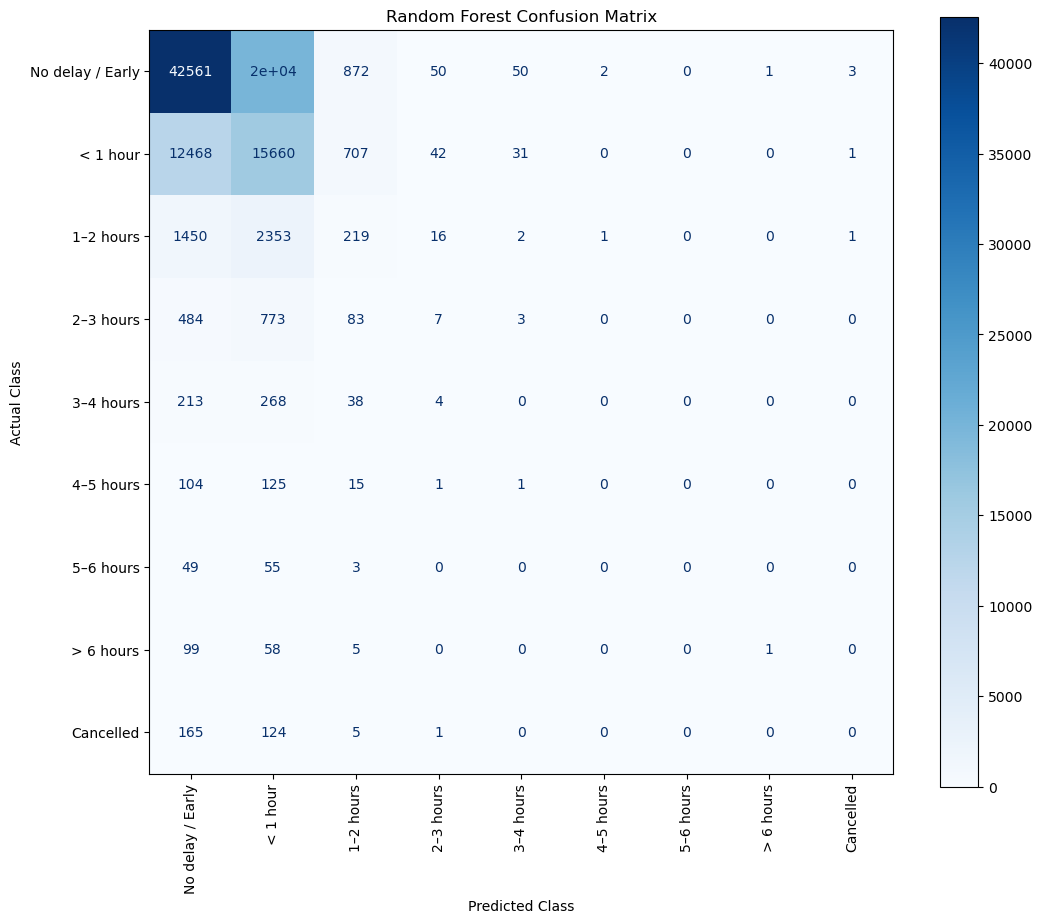

In [11]:
# create confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))


cm = confusion_matrix(two_y_test, two_y_test_pred)

class_labels = [
    "No delay / Early",
    "< 1 hour",
    "1–2 hours",
    "2–3 hours",
    "3–4 hours",
    "4–5 hours",
    "5–6 hours",
    "> 6 hours",
    "Cancelled"
]

# display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

# plot confusion matrix
disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=90)

plt.show()

**4 hour random forest**

In [12]:
# train the model
rf_model.fit(four_X_train_processed, four_y_train)

# evaluate accuracy on the model

# predict train, validation, and test data
four_y_train_pred = rf_model.predict(four_X_train_processed)
four_y_val_pred = rf_model.predict(four_X_val_processed)
four_y_test_pred = rf_model.predict(four_X_test_processed)

# calculate accuracy
train_accuracy = accuracy_score(four_y_train, four_y_train_pred)
val_accuracy = accuracy_score(four_y_val, four_y_val_pred)
test_accuracy = accuracy_score(four_y_test, four_y_test_pred)

# print outputs
print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(
    f"Difference between training and validation accuracy: "
    f"{abs(train_accuracy - val_accuracy):.3f}"
)

Training Accuracy: 0.843
Validation Accuracy: 0.573
Test Accuracy: 0.582
Difference between training and validation accuracy: 0.270


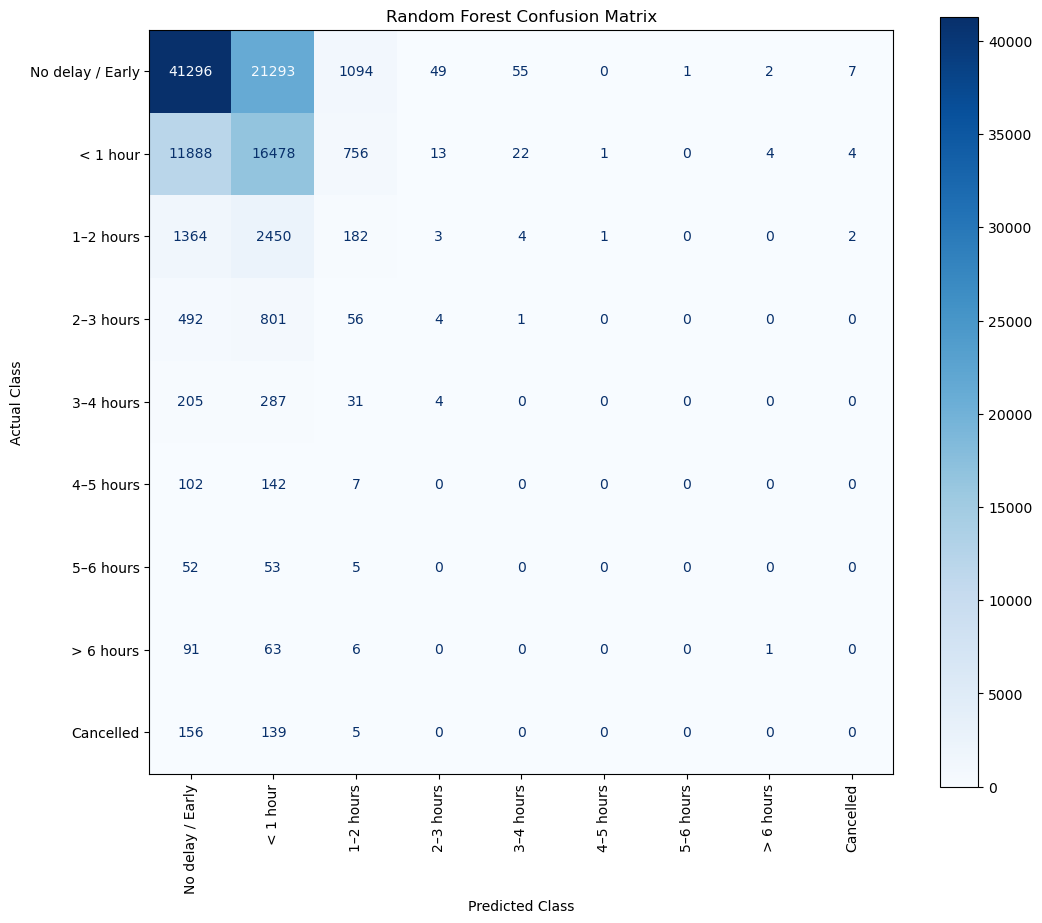

In [13]:
# create confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))


cm = confusion_matrix(four_y_test, four_y_test_pred)

class_labels = [
    "No delay / Early",
    "< 1 hour",
    "1–2 hours",
    "2–3 hours",
    "3–4 hours",
    "4–5 hours",
    "5–6 hours",
    "> 6 hours",
    "Cancelled"
]

# display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

# plot confusion matrix
disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=90)

plt.show()